In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


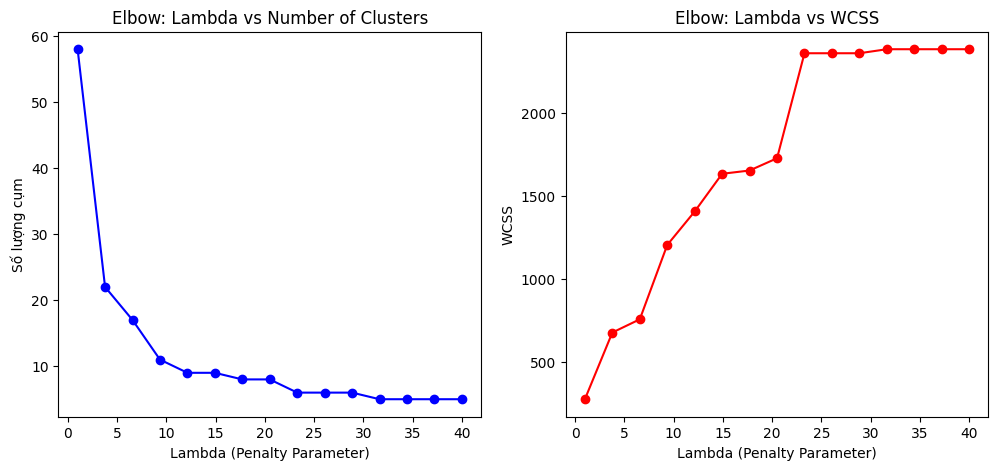

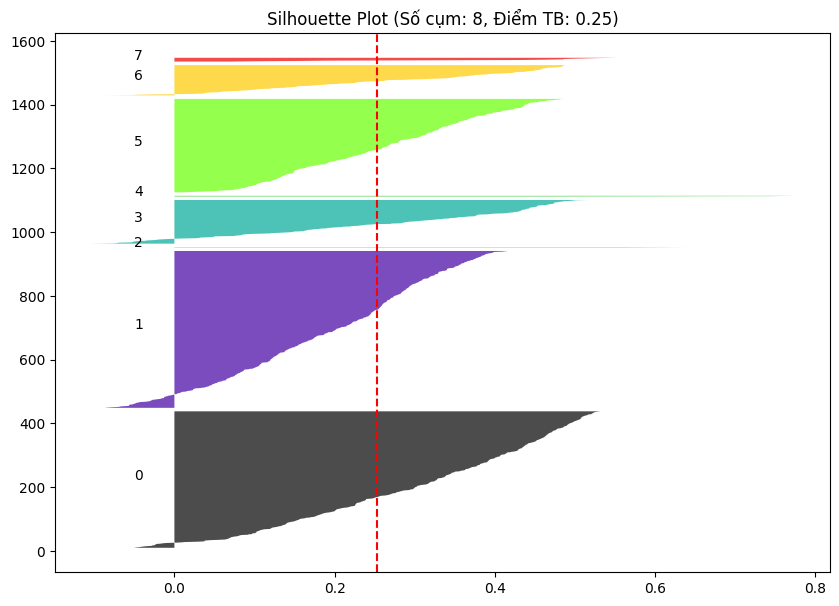

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score

# --- 1. CHUẨN BỊ DỮ LIỆU ---
df = pd.read_csv("/content/drive/MyDrive/PTTK/Clean_Online_Sales_with_VIP_type.csv")
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

#  Coupon_Used (1 nếu Used, 0 nếu Not Used)
df['Is_Coupon_Used'] = df['Coupon_Status'].apply(lambda x: 1 if x == 'Used' else 0)

#  RFM + Coupon_Ratio
ref_date = df['Transaction_Date'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'Transaction_Date': lambda x: (ref_date - x.max()).days, # Recency
    'Transaction_ID': 'nunique',                             # Frequency
    'Transaction_Value': 'sum',                              # Monetary
    'Is_Coupon_Used': 'mean'                                 # Coupon_Ratio
}).reset_index()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Coupon_Ratio']

# Scaling features for distance-based clustering
features = ['Recency', 'Frequency', 'Monetary', 'Coupon_Ratio']
X_scaled = StandardScaler().fit_transform(rfm[features])

# --- 2. THUẬT TOÁN DP-MEANS ---
def dp_means(X, lambd, max_iter=50):
    n_samples = X.shape[0]
    centers = [np.mean(X, axis=0)]
    assignments = np.zeros(n_samples, dtype=int)
    for _ in range(max_iter):
        changed = False
        for j in range(n_samples):
            distances = [np.sum((X[j] - c)**2) for c in centers]
            min_dist = min(distances)
            if min_dist > lambd:
                centers.append(X[j])
                assignments[j] = len(centers) - 1
                changed = True
            else:
                new_assign = np.argmin(distances)
                if assignments[j] != new_assign:
                    assignments[j] = new_assign
                    changed = True
        new_centers = [np.mean(X[assignments == k], axis=0) for k in range(len(centers))]
        centers = new_centers
        if not changed: break
    return np.array(centers), assignments

# Chạy thuật toán
centers, clusters = dp_means(X_scaled, lambd=20.0)
rfm['Cluster'] = clusters
import matplotlib.pyplot as plt

# --- VẼ BIỂU ĐỒ ELBOW (Dựa trên Lambda) ---
lambdas = np.linspace(1, 40, 15) # Thử nghiệm các mức Lambda từ 1 đến 40
cluster_counts = []
wcss = []

for l in lambdas:
    centers, assign = dp_means(X_scaled, l)
    cluster_counts.append(len(centers))
    # Tính WCSS (Sai số bình phương trong cụm)
    current_wcss = 0
    for k in range(len(centers)):
        pts = X_scaled[assign == k]
        if len(pts) > 0:
            current_wcss += np.sum((pts - centers[k])**2)
    wcss.append(current_wcss)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lambdas, cluster_counts, 'bo-')
plt.title("Elbow: Lambda vs Number of Clusters")
plt.xlabel("Lambda (Penalty Parameter)")
plt.ylabel("Số lượng cụm")

plt.subplot(1, 2, 2)
plt.plot(lambdas, wcss, 'ro-')
plt.title("Elbow: Lambda vs WCSS")
plt.xlabel("Lambda (Penalty Parameter)")
plt.ylabel("WCSS")
plt.savefig("dpmeans_elbow_charts.png")

# --- 3. CLUSTERING VALIDATION (SILHOUETTE) ---
avg_score = silhouette_score(X_scaled, clusters)
sample_values = silhouette_samples(X_scaled, clusters)
n_clusters = len(np.unique(clusters))

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(n_clusters):
    ith_cluster_v = sample_values[clusters == i]
    ith_cluster_v.sort()
    size_i = ith_cluster_v.shape[0]
    y_upper = y_lower + size_i
    color = plt.cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_v, facecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

ax.set_title(f"Silhouette Plot (Số cụm: {n_clusters}, Điểm TB: {avg_score:.2f})")
ax.axvline(x=avg_score, color="red", linestyle="--")
plt.savefig("dpmeans_validation.png")

# Lưu kết quả
rfm.to_csv("Final_DPMeans_Results.csv", index=False)

In [ ]:
# 1. Kết hợp nhãn cụm vào bảng dữ liệu RFM ban đầu
# (Bước này đã có trong code trước, đảm bảo rfm['Cluster'] đã tồn tại)

# 2. Đặt tên file theo thời gian hoặc phiên bản để dễ quản lý
file_name = "DPMeans_Clustering_Results.csv"

# 3. Lưu file
# index=False giúp file sạch hơn (không có cột số thứ tự thừa)
rfm.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"--- Đã lưu kết quả thành công vào file: {file_name} ---")
print(f"Tổng số khách hàng đã phân cụm: {len(rfm)}")

--- Đã lưu kết quả thành công vào file: DPMeans_Clustering_Results.csv ---
Tổng số khách hàng đã phân cụm: 1468


In [ ]:
from google.colab import files
files.download('DPMeans_Clustering_Results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>